# 04 — The Role Question (H2 times through order, H5 workload)

Implements `s3_design_spec.md`. Results only — interpretation belongs to the project owner.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RAW = Path("../data/raw")
FIG = Path("../figures")
B = 10_000
rng = np.random.default_rng(3)
pd.set_option("display.width", 200)

WHIFF = {"swinging_strike", "swinging_strike_blocked", "missed_bunt"}
SWING = WHIFF | {"foul", "foul_tip", "foul_bunt", "bunt_foul_tip", "hit_into_play"}
STRIKEOUT = {"strikeout", "strikeout_double_play"}

## Load, assign role / TTO / pitch-count bucket

In [2]:
def load(name, seasons):
    d = pd.concat([pd.read_csv(RAW / f"{name}_statcast_mlb_{y}.csv", low_memory=False).assign(season=y)
                   for y in seasons], ignore_index=True)
    d = d[d.game_type != "S"]
    d = d[~((d.season == 2026) & d.game_type.isin(["F", "D", "L", "W"]))]
    d["pa_id"] = d.game_pk.astype(str) + "_" + d.at_bat_number.astype(str)
    d = d[~d.pa_id.isin(d.loc[d.events == "intent_walk", "pa_id"])]
    d = d.sort_values(["game_pk", "at_bat_number", "pitch_number"]).reset_index(drop=True)
    d["role"] = np.where(d.groupby("game_pk").inning.transform("min") == 1, "start", "relief")
    d["n"] = d.groupby("game_pk").cumcount() + 1
    d["pa_n0"] = d.groupby("pa_id").n.transform("min")
    d["bucket"] = pd.cut(d.pa_n0, [0, 25, 50, 75, 999], labels=["1-25", "26-50", "51-75", "76+"]).astype(str)
    d["pitcher_name"] = name
    return d

sas = load("sasaki", [2025, 2026])
yam = load("yamamoto", [2024, 2025, 2026])
yam = yam[yam.role == "start"]
pitches = pd.concat([sas, yam], ignore_index=True)

tiers = []
for y in [2024, 2025, 2026]:
    x = pd.read_csv(RAW / f"batter_xwoba_{y}.csv")
    lg = (x.est_woba * x.pa).sum() / x.pa.sum()
    x["adj"] = (x.pa * x.est_woba + 100 * lg) / (x.pa + 100)
    s = x.sort_values("adj")
    med = s.adj[(s.pa.cumsum() / s.pa.sum()) >= 0.5].iloc[0]
    x["tier"] = np.where(x.adj >= med, "High", "Low")
    tiers.append(x[["player_id", "tier"]].assign(season=y))
pitches = pitches.merge(pd.concat(tiers), left_on=["batter", "season"], right_on=["player_id", "season"], how="left")
print("Pitches with no tier:", pitches.tier.isna().sum())

/var/folders/sm/_ttyl33555v_1wtcfv790wcr0000gn/T/ipykernel_15926/402098225.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d = pd.concat([pd.read_csv(RAW / f"{name}_statcast_mlb_{y}.csv", low_memory=False).assign(season=y)
/var/folders/sm/_ttyl33555v_1wtcfv790wcr0000gn/T/ipykernel_15926/402098225.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d = pd.concat([pd.read_csv(RAW / f"{name}_statcast_mlb_{y}.csv", low_memory=False).assign(season=y)
/var/folders/sm/_ttyl33555v_1wtcfv790wcr0000gn/T/ipykernel_15926/402098225.py:6:

Pitches with no tier: 0


/var/folders/sm/_ttyl33555v_1wtcfv790wcr0000gn/T/ipykernel_15926/402098225.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d = pd.concat([pd.read_csv(RAW / f"{name}_statcast_mlb_{y}.csv", low_memory=False).assign(season=y)
/var/folders/sm/_ttyl33555v_1wtcfv790wcr0000gn/T/ipykernel_15926/402098225.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d["pa_id"] = d.game_pk.astype(str) + "_" + d.at_bat_number.astype(str)
/var/folders/sm/_ttyl33555v_1wtcfv790wcr0000gn/T/ipykernel_15926/402098225.py:9: PerformanceWarning: DataFram

## Pitch-level and PA-level tables

In [3]:
P = pitches[(pitches.description != "pitchout") & pitches.plate_x.notna() & pitches.release_speed.notna()].copy()
P["swing"] = P.description.isin(SWING)
P["whiff"] = P.description.isin(WHIFF)
P["in_zone"] = P.zone.between(1, 9)
P["is_ff"] = P.pitch_type == "FF"
P["ff_velo"] = np.where(P.is_ff, P.release_speed, 0.0)

last = pitches[pitches.events.notna()].copy()
last["xw_num"] = np.where(last.estimated_woba_using_speedangle.notna(), last.estimated_woba_using_speedangle, last.woba_value)
last["xw_den"] = last.woba_denom.fillna(0)
last["k"] = last.events.isin(STRIKEOUT)
last["bb"] = last.events == "walk"
last["one"] = 1
PA = last[["pitcher_name", "season", "game_pk", "role", "tier", "n_thruorder_pitcher", "bucket", "xw_num", "xw_den", "k", "bb", "one"]]
PA.groupby(["pitcher_name", "role", "n_thruorder_pitcher"]).size().unstack()

n_thruorder_pitcher      1      2      3     4
pitcher_name role                             
sasaki       relief   61.0    NaN    NaN   NaN
             start   280.0  269.0  118.0   NaN
yamamoto     start   764.0  728.0  457.0  20.0

## Tier-standardized cluster bootstrap
`W` = game resampling weights (row 0 = observed). Same `W` across TTO / bucket subsets → paired contrasts.

In [4]:
def make_w(games):
    return np.vstack([np.ones(len(games)), rng.multinomial(len(games), np.full(len(games), 1 / len(games)), size=B)])

def rate(df, num, den, games, W, scale=1.0):
    per, ns = [], []
    for tier in ["Low", "High"]:
        s = df[df.tier == tier].groupby("game_pk")[[num, den]].sum().reindex(games, fill_value=0)
        with np.errstate(invalid="ignore", divide="ignore"):
            per.append(scale * (W @ s[num].values) / (W @ s[den].values))
        ns.append(int(s[den].sum()))
    return (per[0] + per[1]) / 2, ns

def ci(a):
    b = a[1:][~np.isnan(a[1:])]
    return (np.nan, np.nan) if len(b) == 0 else (np.percentile(b, 2.5), np.percentile(b, 97.5))

def boot_p(a):
    """Two-sided bootstrap p-value for 'value = 0'; a[0] is the observed value, a[1:] the draws (floored at 1/B)."""
    b = a[1:][~np.isnan(a[1:])]
    return max(2 * min((b <= 0).mean(), (b >= 0).mean()), 1 / len(b)) if len(b) else np.nan

PVALS = []  # every pre-registered Section 3 test, for the multiple-comparison check

def fmt(a, digits=1):
    lo, hi = ci(a)
    return f"{a[0]:.{digits}f} [{lo:.{digits}f}, {hi:.{digits}f}]"

## H2 — Times through the order (starts)

In [5]:
def tto_metrics(pitcher, seasons):
    pa = PA[(PA.pitcher_name == pitcher) & (PA.role == "start") & PA.season.isin(seasons)]
    pp = P[(P.pitcher_name == pitcher) & (P.role == "start") & P.season.isin(seasons)]
    games = np.sort(pa.game_pk.unique())
    W = make_w(games)
    out = {}
    for t in [1, 2, 3]:
        a, b = pa[pa.n_thruorder_pitcher == t], pp[pp.n_thruorder_pitcher == t]
        out[(t, "xwOBA")] = rate(a, "xw_num", "xw_den", games, W)
        out[(t, "K%")] = rate(a, "k", "one", games, W, 100)
        out[(t, "BB%")] = rate(a, "bb", "one", games, W, 100)
        out[(t, "whiff/swing")] = rate(b[b.swing], "whiff", "swing", games, W, 100)
    return out

TTO = {("sasaki", "2025+26"): tto_metrics("sasaki", [2025, 2026]),
       ("sasaki", "2026"): tto_metrics("sasaki", [2026]),
       ("yamamoto", "2024-26"): tto_metrics("yamamoto", [2024, 2025, 2026]),
       ("yamamoto", "2026"): tto_metrics("yamamoto", [2026])}
rows = []
for key, m in TTO.items():
    for metric in ["xwOBA", "K%", "BB%", "whiff/swing"]:
        d = 3 if metric == "xwOBA" else 1
        row = {"pitcher": key[0], "sample": key[1], "metric": metric}
        for t in [1, 2, 3]:
            row[f"TTO{t}"] = fmt(m[(t, metric)][0], d)
            row[f"n{t} (low/high)"] = m[(t, metric)][1]
        rows.append(row)
tto_table = pd.DataFrame(rows)
tto_table.to_csv("../data/processed/s3_tto.csv", index=False)
tto_table

,pitcher,sample,metric,TTO1,n1 (low/high),TTO2,n2 (low/high),TTO3,n3 (low/high)
0,sasaki,2025+26,xwOBA,"0.337 [0.297, 0.375]","[129, 148]","0.322 [0.276, 0.365]","[125, 143]","0.335 [0.262, 0.412]","[36, 81]"
1,sasaki,2025+26,K%,"21.9 [16.8, 27.4]","[131, 149]","20.9 [17.3, 24.5]","[125, 144]","19.2 [11.0, 28.5]","[37, 81]"
2,sasaki,2025+26,BB%,"9.7 [6.5, 13.1]","[131, 149]","12.0 [8.5, 16.0]","[125, 144]","11.3 [4.8, 18.8]","[37, 81]"
3,sasaki,2025+26,whiff/swing,"26.4 [21.8, 31.0]","[263, 295]","24.1 [20.4, 27.9]","[249, 250]","26.4 [19.9, 33.6]","[81, 147]"
4,sasaki,2026,xwOBA,"0.319 [0.276, 0.359]","[97, 109]","0.318 [0.266, 0.372]","[98, 109]","0.326 [0.237, 0.419]","[27, 69]"
5,sasaki,2026,K%,"25.2 [19.3, 31.6]","[99, 109]","20.3 [16.4, 24.2]","[98, 110]","22.0 [12.2, 32.9]","[28, 69]"
6,sasaki,2026,BB%,"8.7 [5.3, 12.3]","[99, 109]","10.5 [6.4, 15.0]","[98, 110]","12.2 [4.3, 21.2]","[28, 69]"
7,sasaki,2026,whiff/swing,"29.7 [24.8, 34.6]","[216, 226]","23.2 [18.9, 27.5]","[205, 196]","29.1 [21.2, 37.8]","[60, 127]"
8,yamamoto,2024-26,xwOBA,"0.267 [0.244, 0.290]","[371, 388]","0.273 [0.248, 0.300]","[352, 374]","0.278 [0.247, 0.308]","[182, 271]"
9,yamamoto,2024-26,K%,"28.3 [25.0, 31.6]","[374, 390]","27.1 [24.1, 30.0]","[353, 375]","24.8 [21.1, 28.8]","[184, 273]"


## H2 — TTO penalties and pre-registered verdict

In [6]:
rows = []
for key, m in TTO.items():
    for metric in ["xwOBA", "K%", "BB%", "whiff/swing"]:
        d = 3 if metric == "xwOBA" else 1
        for t in [2, 3]:
            pen = m[(t, metric)][0] - m[(1, metric)][0]
            rows.append({"pitcher": key[0], "sample": key[1], "metric": metric, "penalty": f"TTO{t}−TTO1", "value": fmt(pen, d)})
penalties = pd.DataFrame(rows)
penalties.pivot_table(index=["metric", "penalty"], columns=["pitcher", "sample"], values="value", aggfunc="first", sort=False)

pitcher                                sasaki                                       yamamoto                       
sample                                2025+26                    2026                2024-26                   2026
metric      penalty                                                                                                
xwOBA       TTO2−TTO1  -0.015 [-0.074, 0.044]  -0.001 [-0.062, 0.064]  0.006 [-0.029, 0.041]  0.043 [-0.021, 0.107]
            TTO3−TTO1  -0.002 [-0.086, 0.091]   0.007 [-0.100, 0.121]  0.011 [-0.027, 0.048]  0.046 [-0.014, 0.109]
K%          TTO2−TTO1        -1.1 [-7.3, 4.9]       -4.9 [-12.1, 1.4]       -1.2 [-5.8, 3.6]      -4.7 [-11.5, 2.2]
            TTO3−TTO1       -2.7 [-12.8, 7.9]       -3.2 [-15.4, 9.0]       -3.5 [-8.1, 1.2]      -7.4 [-15.1, 0.5]
BB%         TTO2−TTO1         2.3 [-2.3, 7.0]         1.8 [-3.7, 7.5]       -1.3 [-3.5, 0.7]       -0.7 [-4.1, 2.4]
            TTO3−TTO1        1.7 [-5.5, 10.1]        3.5 [-5.0, 13.6]       -0.6 [-3.5, 2.3]        0.6 [-3.6, 4.9]
whiff/swing TTO2−TTO1        -2.4 [-7.3, 2.9]      -6.6 [-11.7, -1.5]        0.2 [-3.7, 4.1]        0.6 [-4.2, 5.5]
            TTO3−TTO1        -0.1 [-9.5, 9.9]      -0.7 [-12.2, 12.0]       -2.6 [-6.5, 1.0]       -4.8 [-9.9, 0.1]

In [7]:
for s_key, y_key in [(("sasaki", "2025+26"), ("yamamoto", "2024-26")), (("sasaki", "2026"), ("yamamoto", "2026"))]:
    s_pen = TTO[s_key][(3, "xwOBA")][0] - TTO[s_key][(1, "xwOBA")][0]
    y_pen = TTO[y_key][(3, "xwOBA")][0] - TTO[y_key][(1, "xwOBA")][0]
    own_lo, own_hi = ci(s_pen)
    diff = s_pen - y_pen
    lo, hi = ci(diff)
    own = "meaningful" if (s_pen[0] >= 0.030 and own_lo > 0) else "not meaningful"
    verdict = "Supported" if (diff[0] >= 0.030 and lo > 0) else ("Contradicted" if hi < 0 else "Not supported")
    PVALS.append({"test": f"H2 Sasaki−Yamamoto TTO3 penalty ({s_key[1]})", "est": diff[0], "p_boot": boot_p(diff), "meaningful": verdict == "Supported"})
    print(f"{s_key[1]} vs {y_key[1]}: Sasaki TTO3−TTO1 xwOBA {s_pen[0]:+.3f} [{own_lo:+.3f}, {own_hi:+.3f}] ({own}); "
          f"Yamamoto {y_pen[0]:+.3f}; Sasaki − Yamamoto {diff[0]:+.3f} [{lo:+.3f}, {hi:+.3f}] -> H2 {verdict}")

2025+26 vs 2024-26: Sasaki TTO3−TTO1 xwOBA -0.002 [-0.086, +0.091] (not meaningful); Yamamoto +0.011; Sasaki − Yamamoto -0.012 [-0.105, +0.090] -> H2 Not supported
2026 vs 2026: Sasaki TTO3−TTO1 xwOBA +0.007 [-0.100, +0.121] (not meaningful); Yamamoto +0.046; Sasaki − Yamamoto -0.039 [-0.160, +0.092] -> H2 Not supported


## Pitch mix by TTO (descriptive, starts)

In [8]:
mix = P[P.role == "start"].groupby(["pitcher_name", "season", "n_thruorder_pitcher"]).pitch_type.value_counts(normalize=True).mul(100).round(1)
mix = mix.unstack().fillna(0)
mix[mix.index.get_level_values("n_thruorder_pitcher") <= 3]

pitch_type                                 CU    FC    FF    FO    FS    SI    SL    ST
pitcher_name season n_thruorder_pitcher                                                
sasaki       2025   1                     0.0   0.0  57.6  24.9   0.0   0.0   0.0  17.5
                    2                     0.0   0.0  45.0  38.3   0.0   0.0   0.0  16.7
                    3                     0.0   0.0  41.4  42.5   0.0   0.0   0.0  16.1
             2026   1                     0.0   0.0  42.8   5.0  29.4   0.0  22.8   0.0
                    2                     0.0   0.0  43.0   8.8  27.1   0.0  21.2   0.0
                    3                     0.0   0.0  37.4   9.9  33.2   0.0  19.5   0.0
yamamoto     2024   1                    24.5   5.1  44.3   0.0  21.1   1.8   3.1   0.1
                    2                    22.1   6.5  40.1   0.0  23.5   2.8   4.8   0.1
                    3                    18.8   9.6  36.0   0.0  26.1   2.6   6.6   0.4
             2025   1                    18.4   9.4  37.5   0.0  24.3   7.9   2.4   0.1
                    2                    18.5  12.4  33.0   0.0  26.8   7.3   2.1   0.0
                    3                    18.2  13.2  30.9   0.0  25.4   8.2   4.2   0.0
             2026   1                    12.7  13.5  28.6   0.0  27.8  13.4   4.2   0.0
                    2                    14.2  16.6  24.7   0.0  24.0  13.7   6.8   0.0
                    3                    12.8  14.3  24.9   0.0  28.7  11.7   7.7   0.0

## H5(a) — Days off before a start (5 vs. 6+)

In [9]:
def start_logs(name):
    g = pd.read_csv(RAW / f"{name}_game_logs.csv")
    g["date"] = pd.to_datetime(g.date)
    g = g.sort_values("date")
    g["days_off"] = g.date.diff().dt.days - 1
    g.loc[g.season != g.season.shift(), "days_off"] = np.nan
    g = g[(g.gamesStarted == 1) & ~((g.season == 2026) & (g.game_type == "P"))]
    g["start_no"] = g.groupby("season").cumcount() + 1
    return g[["season", "date", "game_pk", "days_off", "start_no", "runs", "inningsPitched"]].assign(pitcher_name=name)

logs = pd.concat([start_logs("sasaki"), start_logs("yamamoto")], ignore_index=True)
per_start = (P[P.role == "start"].groupby("game_pk").agg(ff_sum=("ff_velo", "sum"), ff_n=("is_ff", "sum"),
                                                         whiffs=("whiff", "sum"), swings=("swing", "sum"))
             .join(PA[PA.role == "start"].groupby("game_pk")[["xw_num", "xw_den"]].sum()))
logs = logs.merge(per_start, left_on="game_pk", right_index=True)
logs["ff_velo"] = logs.ff_sum / logs.ff_n
logs["xwoba"] = logs.xw_num / logs.xw_den
logs["rest_bucket"] = np.select([logs.days_off == 5, logs.days_off.between(6, 10)], ["5 days off", "6+ days off"], "excluded")
logs.groupby(["pitcher_name", "rest_bucket"]).size().unstack()

rest_bucket,5 days off,6+ days off,excluded
pitcher_name,,,
sasaki,11,18,2
yamamoto,45,36,4


In [10]:
def pooled_boot(df, num, den):
    v = df[[num, den]].values
    idx = rng.integers(0, len(v), size=(B, len(v)))
    draws = v[idx, 0].sum(1) / v[idx, 1].sum(1)
    return np.concatenate([[v[:, 0].sum() / v[:, 1].sum()], draws])

rows = []
for name in ["sasaki", "yamamoto"]:
    L = logs[logs.pitcher_name == name]
    a, b = L[L.rest_bucket == "5 days off"], L[L.rest_bucket == "6+ days off"]
    for label, num, den, d in [("FF velo", "ff_sum", "ff_n", 1), ("xwOBA", "xw_num", "xw_den", 3), ("whiff/swing %", "whiffs", "swings", 1)]:
        scale = 100 if "%" in label else 1
        ra, rb = scale * pooled_boot(a, num, den), scale * pooled_boot(b, num, den)
        diff = ra - rb
        lo, hi = ci(diff)
        limit = {"FF velo": 1.0, "xwOBA": 0.040}.get(label)
        verdict = "" if limit is None else ("Meaningful" if (abs(diff[0]) >= limit and (lo > 0 or hi < 0)) else "Not meaningful")
        if limit is not None:
            PVALS.append({"test": f"H5a {name} {label} 5 vs 6+ days off", "est": diff[0], "p_boot": boot_p(diff), "meaningful": verdict == "Meaningful"})
        rows.append({"pitcher": name, "metric": label, "5 days off": fmt(ra, d), "6+ days off": fmt(rb, d),
                     "5 − 6+": fmt(diff, d), "starts (5 / 6+)": (len(a), len(b)), "verdict": verdict})
rest = pd.DataFrame(rows)
rest.to_csv("../data/processed/s3_rest.csv", index=False)
rest

,pitcher,metric,5 days off,6+ days off,5 − 6+,starts (5 / 6+),verdict
0,sasaki,FF velo,"97.5 [96.9, 98.0]","97.2 [96.6, 97.9]","0.2 [-0.7, 1.1]","(11, 18)",Not meaningful
1,sasaki,xwOBA,"0.325 [0.276, 0.375]","0.342 [0.308, 0.373]","-0.017 [-0.075, 0.044]","(11, 18)",Not meaningful
2,sasaki,whiff/swing %,"25.3 [20.5, 29.5]","25.9 [22.3, 29.6]","-0.6 [-6.6, 5.0]","(11, 18)",
3,yamamoto,FF velo,"95.6 [95.4, 95.8]","95.7 [95.5, 96.0]","-0.2 [-0.5, 0.2]","(45, 36)",Not meaningful
4,yamamoto,xwOBA,"0.271 [0.249, 0.293]","0.274 [0.252, 0.297]","-0.004 [-0.035, 0.028]","(45, 36)",Not meaningful
5,yamamoto,whiff/swing %,"25.0 [23.0, 27.0]","26.2 [23.7, 28.5]","-1.2 [-4.3, 2.0]","(45, 36)",


## H5(b) — In-season trend per start

In [11]:
rows = []
for (name, season), L in logs.groupby(["pitcher_name", "season"]):
    for col, d in [("ff_velo", 2), ("xwoba", 4)]:
        x, y = L.start_no.values.astype(float), L[col].values
        slope = np.polyfit(x, y, 1)[0]
        idx = rng.integers(0, len(x), size=(B, len(x)))
        boots = np.array([np.polyfit(x[i], y[i], 1)[0] if len(np.unique(x[i])) > 1 else np.nan for i in idx])
        lo, hi = ci(np.concatenate([[slope], boots]))
        span = slope * (len(x) - 1)
        verdict = ""
        if col == "ff_velo":
            verdict = "Meaningful" if ((lo > 0 or hi < 0) and abs(span) >= 1.0) else "Not meaningful"
        if col == "ff_velo":
            PVALS.append({"test": f"H5b {name} {season} FF velo slope", "est": slope,
                          "p_boot": boot_p(np.concatenate([[slope], boots])), "meaningful": verdict == "Meaningful"})
        rows.append({"pitcher": name, "season": season, "metric": col, "starts": len(x), "slope per start": round(slope, d),
                     "ci": f"[{lo:.{d}f}, {hi:.{d}f}]", "implied change over season": round(span, d), "verdict": verdict})
trend = pd.DataFrame(rows)
trend.to_csv("../data/processed/s3_trend.csv", index=False)
trend

,pitcher,season,metric,starts,slope per start,ci,implied change over season,verdict
0,sasaki,2025,ff_velo,8,-0.3900,"[-0.60, -0.18]",-2.7500,Meaningful
1,sasaki,2025,xwoba,8,0.0156,"[0.0030, 0.0298]",0.1093,
2,sasaki,2026,ff_velo,23,0.0700,"[0.02, 0.14]",1.6000,Meaningful
3,sasaki,2026,xwoba,23,-0.0015,"[-0.0064, 0.0033]",-0.0322,
4,yamamoto,2024,ff_velo,22,0.0200,"[-0.01, 0.05]",0.3800,Not meaningful
5,yamamoto,2024,xwoba,22,0.0003,"[-0.0049, 0.0054]",0.0055,
6,yamamoto,2025,ff_velo,35,0.0300,"[0.01, 0.05]",1.0400,Meaningful
7,yamamoto,2025,xwoba,35,0.0002,"[-0.0020, 0.0023]",0.0083,
8,yamamoto,2026,ff_velo,28,0.0200,"[-0.00, 0.05]",0.6400,Not meaningful
9,yamamoto,2026,xwoba,28,-0.0035,"[-0.0060, -0.0012]",-0.0939,


## H5(c) — Within-game decay by pitch-count bucket (starts) + Sasaki relief reference

In [12]:
BUCKETS = ["1-25", "26-50", "51-75", "76+"]
DECAY = {}
for name in ["sasaki", "yamamoto"]:
    pp = P[(P.pitcher_name == name) & (P.role == "start")]
    pa = PA[(PA.pitcher_name == name) & (PA.role == "start")]
    games = np.sort(pp.game_pk.unique())
    W = make_w(games)
    for bk in BUCKETS:
        b, a = pp[pp.bucket == bk], pa[pa.bucket == bk]
        DECAY[(name, bk, "FF velo")] = rate(b[b.is_ff], "ff_velo", "is_ff", games, W)
        DECAY[(name, bk, "whiff/swing")] = rate(b[b.swing], "whiff", "swing", games, W, 100)
        DECAY[(name, bk, "zone%")] = rate(b.assign(one=1), "in_zone", "one", games, W, 100)
        DECAY[(name, bk, "xwOBA")] = rate(a, "xw_num", "xw_den", games, W)
# Sasaki relief reference (all relief pitches)
rp, ra = P[(P.pitcher_name == "sasaki") & (P.role == "relief")], PA[(PA.pitcher_name == "sasaki") & (PA.role == "relief")]
rg = np.sort(rp.game_pk.unique())
RW = make_w(rg)
RELIEF = {"FF velo": rate(rp[rp.is_ff], "ff_velo", "is_ff", rg, RW), "whiff/swing": rate(rp[rp.swing], "whiff", "swing", rg, RW, 100),
          "zone%": rate(rp.assign(one=1), "in_zone", "one", rg, RW, 100), "xwOBA": rate(ra, "xw_num", "xw_den", rg, RW)}

rows = []
for metric in ["FF velo", "whiff/swing", "zone%", "xwOBA"]:
    d = 3 if metric == "xwOBA" else 1
    for name in ["sasaki", "yamamoto"]:
        row = {"metric": metric, "group": f"{name} starts"}
        for bk in BUCKETS:
            row[bk] = fmt(DECAY[(name, bk, metric)][0], d)
        rows.append(row)
    rows.append({"metric": metric, "group": "sasaki relief (all)", "1-25": fmt(RELIEF[metric][0], d)})
decay = pd.DataFrame(rows)
decay.to_csv("../data/processed/s3_decay.csv", index=False)
decay

,metric,group,1-25,26-50,51-75,76+
0,FF velo,sasaki starts,"97.5 [96.9, 98.0]","97.3 [96.9, 97.8]","97.3 [96.8, 97.7]","97.0 [96.6, 97.5]"
1,FF velo,yamamoto starts,"95.9 [95.7, 96.1]","95.7 [95.6, 95.9]","95.4 [95.2, 95.6]","95.5 [95.2, 95.7]"
2,FF velo,sasaki relief (all),"99.0 [98.6, 99.4]",NaN,NaN,NaN
3,whiff/swing,sasaki starts,"26.5 [21.8, 31.1]","26.5 [20.5, 32.7]","24.4 [20.4, 28.7]","27.3 [20.6, 35.1]"
4,whiff/swing,yamamoto starts,"26.4 [23.4, 29.3]","26.5 [23.7, 29.3]","25.7 [23.0, 28.4]","24.0 [20.6, 27.4]"
5,whiff/swing,sasaki relief (all),"29.7 [23.1, 35.5]",NaN,NaN,NaN
6,zone%,sasaki starts,"46.6 [43.9, 49.3]","46.2 [43.7, 48.9]","48.7 [44.3, 53.2]","48.0 [40.5, 55.2]"
7,zone%,yamamoto starts,"48.5 [46.7, 50.4]","50.9 [49.0, 52.7]","49.7 [47.9, 51.6]","49.6 [47.1, 52.3]"
8,zone%,sasaki relief (all),"44.4 [37.5, 51.4]",NaN,NaN,NaN
9,xwOBA,sasaki starts,"0.341 [0.299, 0.382]","0.323 [0.276, 0.372]","0.310 [0.253, 0.371]","0.332 [0.249, 0.421]"


In [13]:
s_drop = DECAY[("sasaki", "76+", "FF velo")][0] - DECAY[("sasaki", "1-25", "FF velo")][0]
y_drop = DECAY[("yamamoto", "76+", "FF velo")][0] - DECAY[("yamamoto", "1-25", "FF velo")][0]
diff = s_drop - y_drop
lo, hi = ci(diff)
print(f"FF velo change, 76+ minus 1-25: Sasaki {fmt(s_drop, 2)} | Yamamoto {fmt(y_drop, 2)} | "
      f"Sasaki − Yamamoto {fmt(diff, 2)} -> H5(c)", "Meaningful" if (diff[0] <= -0.8 and hi < 0) else "Not meaningful")
PVALS.append({"test": "H5c Sasaki−Yamamoto FF velo drop (76+ vs 1-25)", "est": diff[0], "p_boot": boot_p(diff),
              "meaningful": bool(diff[0] <= -0.8 and hi < 0)})
pd.DataFrame(PVALS).to_csv("../data/processed/s3_pvalues.csv", index=False)
pd.DataFrame(PVALS)

FF velo change, 76+ minus 1-25: Sasaki -0.47 [-0.89, 0.02] | Yamamoto -0.47 [-0.72, -0.21] | Sasaki − Yamamoto -0.01 [-0.49, 0.54] -> H5(c) Not meaningful


,test,est,p_boot,meaningful
0,H2 Sasaki−Yamamoto TTO3 penalty (2025+26),-0.012309,0.8160,False
1,H2 Sasaki−Yamamoto TTO3 penalty (2026),-0.039235,0.5684,False
2,H5a sasaki FF velo 5 vs 6+ days off,0.230870,0.6096,False
3,H5a sasaki xwOBA 5 vs 6+ days off,-0.017106,0.6044,False
4,H5a yamamoto FF velo 5 vs 6+ days off,-0.156431,0.3228,False
5,H5a yamamoto xwOBA 5 vs 6+ days off,-0.003740,0.8328,False
6,H5b sasaki 2025 FF velo slope,-0.392245,0.0034,True
7,H5b sasaki 2026 FF velo slope,0.072763,0.0048,True
8,H5b yamamoto 2024 FF velo slope,0.018158,0.2600,False
9,H5b yamamoto 2025 FF velo slope,0.030610,0.0102,True


## Figure 1 — Times through the order

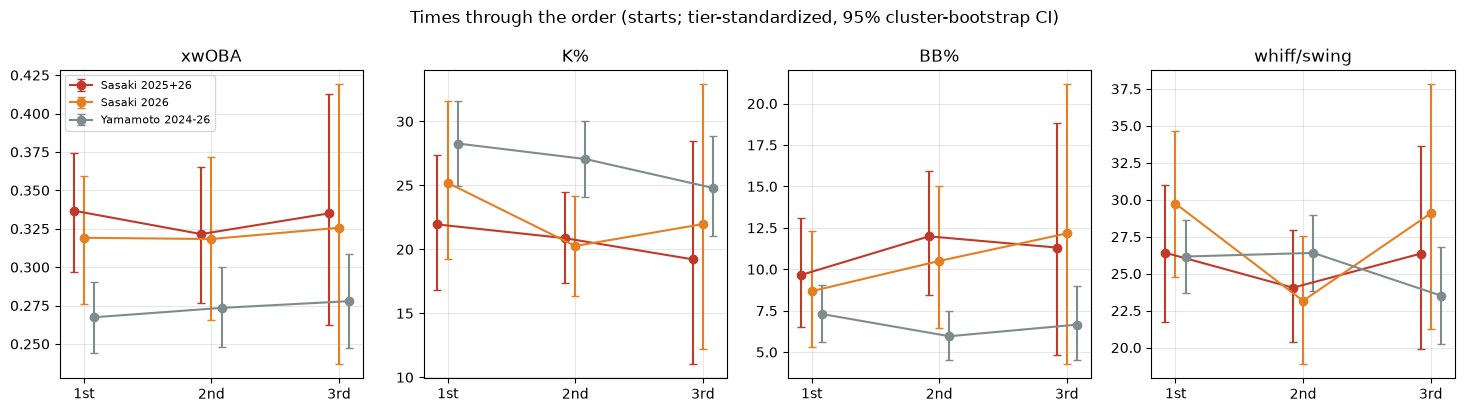

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, metric in zip(axes, ["xwOBA", "K%", "BB%", "whiff/swing"]):
    for key, color, off in [(("sasaki", "2025+26"), "#c0392b", -0.08), (("sasaki", "2026"), "#e67e22", 0.0), (("yamamoto", "2024-26"), "#7f8c8d", 0.08)]:
        est = [TTO[key][(t, metric)][0][0] for t in [1, 2, 3]]
        cis = [ci(TTO[key][(t, metric)][0]) for t in [1, 2, 3]]
        x = np.array([1, 2, 3]) + off
        ax.errorbar(x, est, yerr=[[e - c[0] for e, c in zip(est, cis)], [c[1] - e for e, c in zip(est, cis)]],
                    fmt="-o", color=color, capsize=3, label=f"{key[0].title()} {key[1]}")
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(["1st", "2nd", "3rd"])
    ax.set_title(metric)
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
fig.suptitle("Times through the order (starts; tier-standardized, 95% cluster-bootstrap CI)", y=1.03)
fig.savefig(FIG / "s3_tto.png", dpi=150, bbox_inches="tight")

## Figure 2 — Stamina decay by pitch count

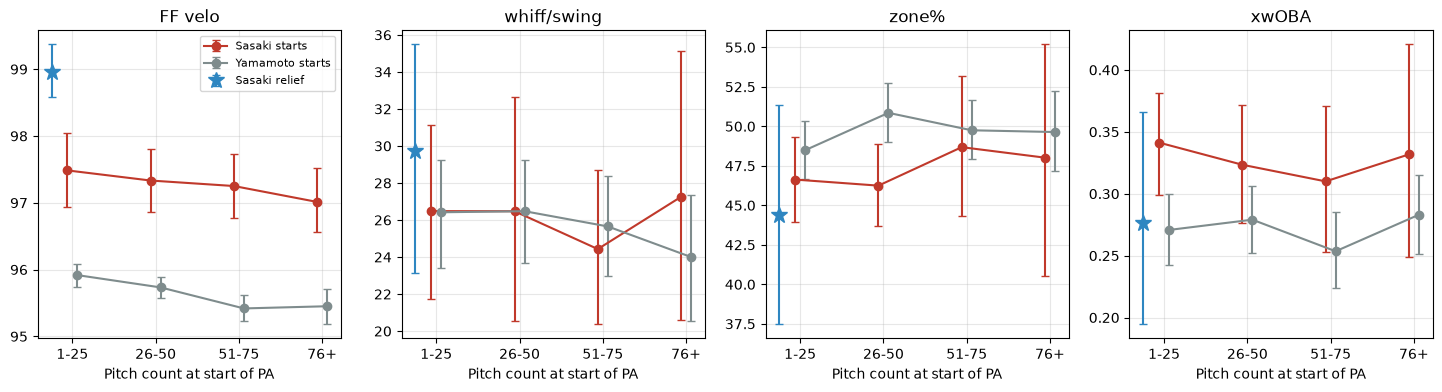

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, metric in zip(axes, ["FF velo", "whiff/swing", "zone%", "xwOBA"]):
    for name, color, off in [("sasaki", "#c0392b", -0.06), ("yamamoto", "#7f8c8d", 0.06)]:
        est = [DECAY[(name, bk, metric)][0][0] for bk in BUCKETS]
        cis = [ci(DECAY[(name, bk, metric)][0]) for bk in BUCKETS]
        x = np.arange(4) + off
        ax.errorbar(x, est, yerr=[[e - c[0] for e, c in zip(est, cis)], [c[1] - e for e, c in zip(est, cis)]],
                    fmt="-o", color=color, capsize=3, label=f"{name.title()} starts")
    r = RELIEF[metric][0]
    rlo, rhi = ci(r)
    ax.errorbar(-0.25, r[0], yerr=[[r[0] - rlo], [rhi - r[0]]], fmt="*", ms=12, color="#2e86c1", capsize=3, label="Sasaki relief")
    ax.set_xticks(range(4))
    ax.set_xticklabels(BUCKETS)
    ax.set_xlabel("Pitch count at start of PA")
    ax.set_title(metric)
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
fig.savefig(FIG / "s3_stamina_decay.png", dpi=150, bbox_inches="tight")

## Figure 3 — Per-start FF velocity across each season

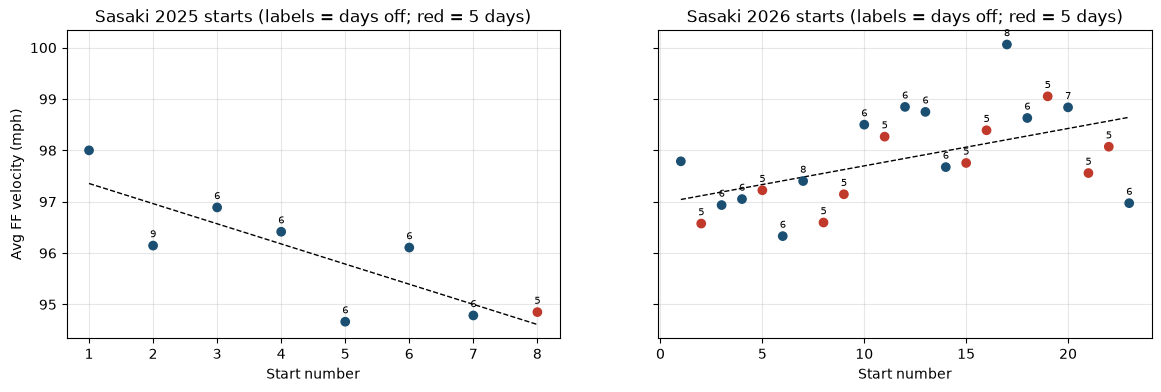

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, season in zip(axes, [2025, 2026]):
    L = logs[(logs.pitcher_name == "sasaki") & (logs.season == season)]
    ax.scatter(L.start_no, L.ff_velo, c=np.where(L.days_off == 5, "#c0392b", "#1b4f72"), zorder=3)
    for _, r in L.iterrows():
        if not np.isnan(r.days_off):
            ax.annotate(int(r.days_off), (r.start_no, r.ff_velo), fontsize=7, xytext=(0, 6), textcoords="offset points", ha="center")
    coef = np.polyfit(L.start_no, L.ff_velo, 1)
    ax.plot(L.start_no, np.polyval(coef, L.start_no), color="black", lw=1, ls="--")
    ax.set_title(f"Sasaki {season} starts (labels = days off; red = 5 days)")
    ax.set_xlabel("Start number")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Avg FF velocity (mph)")
fig.savefig(FIG / "s3_season_velo.png", dpi=150, bbox_inches="tight")